In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("raw_fleet_equipment_data.csv")
df.head()

,Department,Department.1,Equipment Class,Equipment Count
0,Board of,Elections,Van,1.0
1,Board of,Elections,Off Road VehicleEquipment,2.0
2,Circuit,Court,SUV,1.0
3,Community Engagement,Cluster,Pick Up Trucks,8.0
4,Community Engagement,Cluster,Off Road VehicleEquipment,7.0


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Department       57 non-null     object 
 1   Department.1     56 non-null     object 
 2   Equipment Class  57 non-null     object 
 3   Equipment Count  57 non-null     float64
dtypes: float64(1), object(3)
memory usage: 2.1+ KB


Department         5
Department.1       6
Equipment Class    5
Equipment Count    5
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df = df.drop_duplicates()

In [6]:
df.columns = df.columns.str.strip()

In [7]:
df["Department"] = df["Department"].str.strip()

In [8]:
df["Equipment Count"] = df["Equipment Count"].astype(int)

In [9]:
dept_count = df.groupby("Department")["Equipment Count"].sum().sort_values(ascending=False)
dept_count

Department
General                    202
Fire and                   100
Health and Human            96
Enviromnental               72
Correction and              29
Community Engagement        17
County Executives            5
Board of                     3
Circuit                      1
Community Use of Public      1
Consumer                     1
Economic                     1
Name: Equipment Count, dtype: int64

In [10]:
class_count = df.groupby("Equipment Class")["Equipment Count"].sum().sort_values(ascending=False)
class_count

Equipment Class
Sedan                           136
Pick Up Trucks                   94
Van                              73
Off Road VehicleEquipment        59
SUV                              52
Public Safety SUV                31
Public Safety Sedan              18
Public Safety Pick Up Trucks     12
Public Safety Van                12
CUV                              12
Pick Up  Trucks                   8
Heavy Duty                        6
Medium Duty                       5
Public Safety CUV                 4
Public  Safety SUV                2
Public Safety Heavy Duty          2
Public  Safety Sedan              1
Transit Bus                       1
Name: Equipment Count, dtype: int64

In [11]:
dept_count.head()

Department
General             202
Fire and            100
Health and Human     96
Enviromnental        72
Correction and       29
Name: Equipment Count, dtype: int64

In [12]:
dept_count.tail()

Department
Board of                   3
Circuit                    1
Community Use of Public    1
Consumer                   1
Economic                   1
Name: Equipment Count, dtype: int64

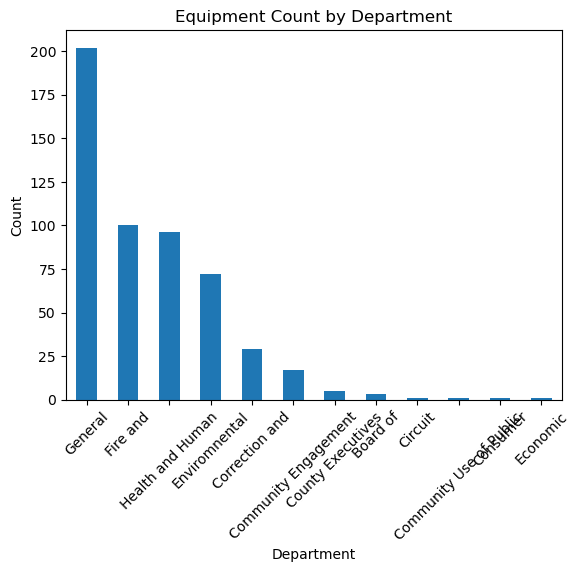

In [13]:
dept_count.plot(kind='bar')
plt.title("Equipment Count by Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

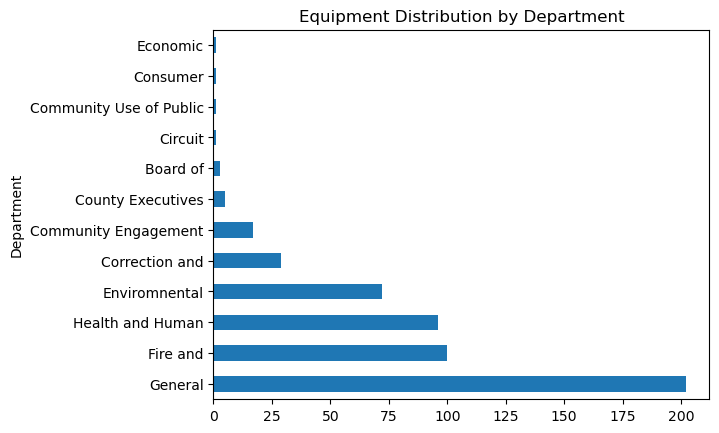

In [14]:
dept_count.plot(kind='barh')
plt.title("Equipment Distribution by Department")
plt.show()

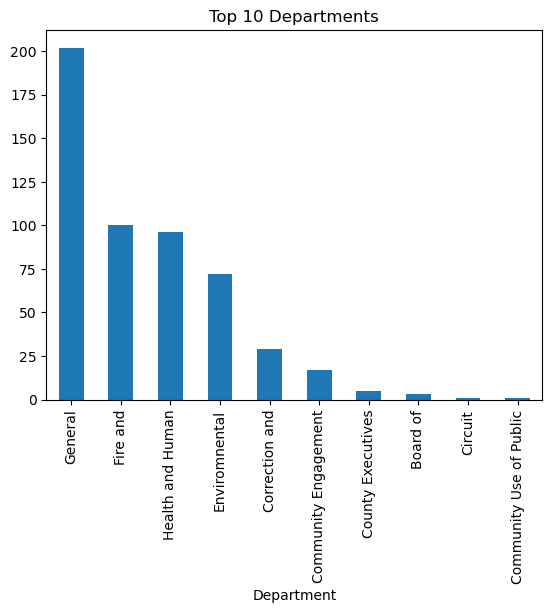

In [15]:
dept_count.head(10).plot(kind='bar')
plt.title("Top 10 Departments")
plt.show()

In [16]:
df.to_csv("cleaned_fleet_python.csv", index=False)